# Przegląd metod AI 2025/26 - Praca domowa II
**Imię i nazwisko:** Mateusz Mioduszewski
**Kierunek, grupa:** Data Science, II semestr, Ps4
**Numer indeksu**: 119159

## 1. Wstęp
Zgodnie z wymogami zadania, kod podzielono na dwa osobne pliki, aby nie wrzucać wszystkiego do jednego pliku. Funkcje do ładowania danych, ogarnięcia braków i generowania EDA trafiły do osobnego pliku `main.py`. W tym pliku skupiamy się na imporcie tych narzędzi, eksperymentach i wyciąganiu wniosków.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_curve, auc

# Import funkcji z main.py
from data_utils import load_heart_data, analyze_missing_data, plot_eda, preprocess_data

import warnings
warnings.filterwarnings('ignore')


#### Zastrzeżenie
Właściwie po co jest...
```python
import warnings
warnings.filterwarnings('ignore')
```
?

W punkcie drugim zadania, tj. bezpośrednio poniżej [Tytuł: Analiza zbioru danych (EDA)] brak zastosowania tej konstrukcji powoduje, że podczas 
urachamiania komórki z kodem pojawia się ostrzeżenie:

```
c:\Users\Mateusz\Desktop\VSCode studia\Task_2\data_utils.py:36: FutureWarning:
Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
  sns.countplot(x='target', data=df, palette='Set2')
```

W nowszych wersjach biblioteki Seaborn (od 0.14.0) użycie koloru (palette) wymaga jawnego wskazania zmiennej kolorującej (hue).
Przez co w starszych wersjach pojawia się takie to ostrzeżenie.

## 2. Analiza zbioru danych (EDA)
W pierwszym kroku ładujemy zbiór i sprawdzamy jego parametry. Sprawdzimy liczebność, braki oraz rozkłady najważniejszych zmiennych wraz z ich korelacją z chorobą serca.

Pobieranie danych z UCI Machine Learning Repository...
Dane załadowane pomyślnie. Kształt zbioru: (303, 14)

--- Brakujące wartości wg kolumn ---
ca      4
thal    2
dtype: int64


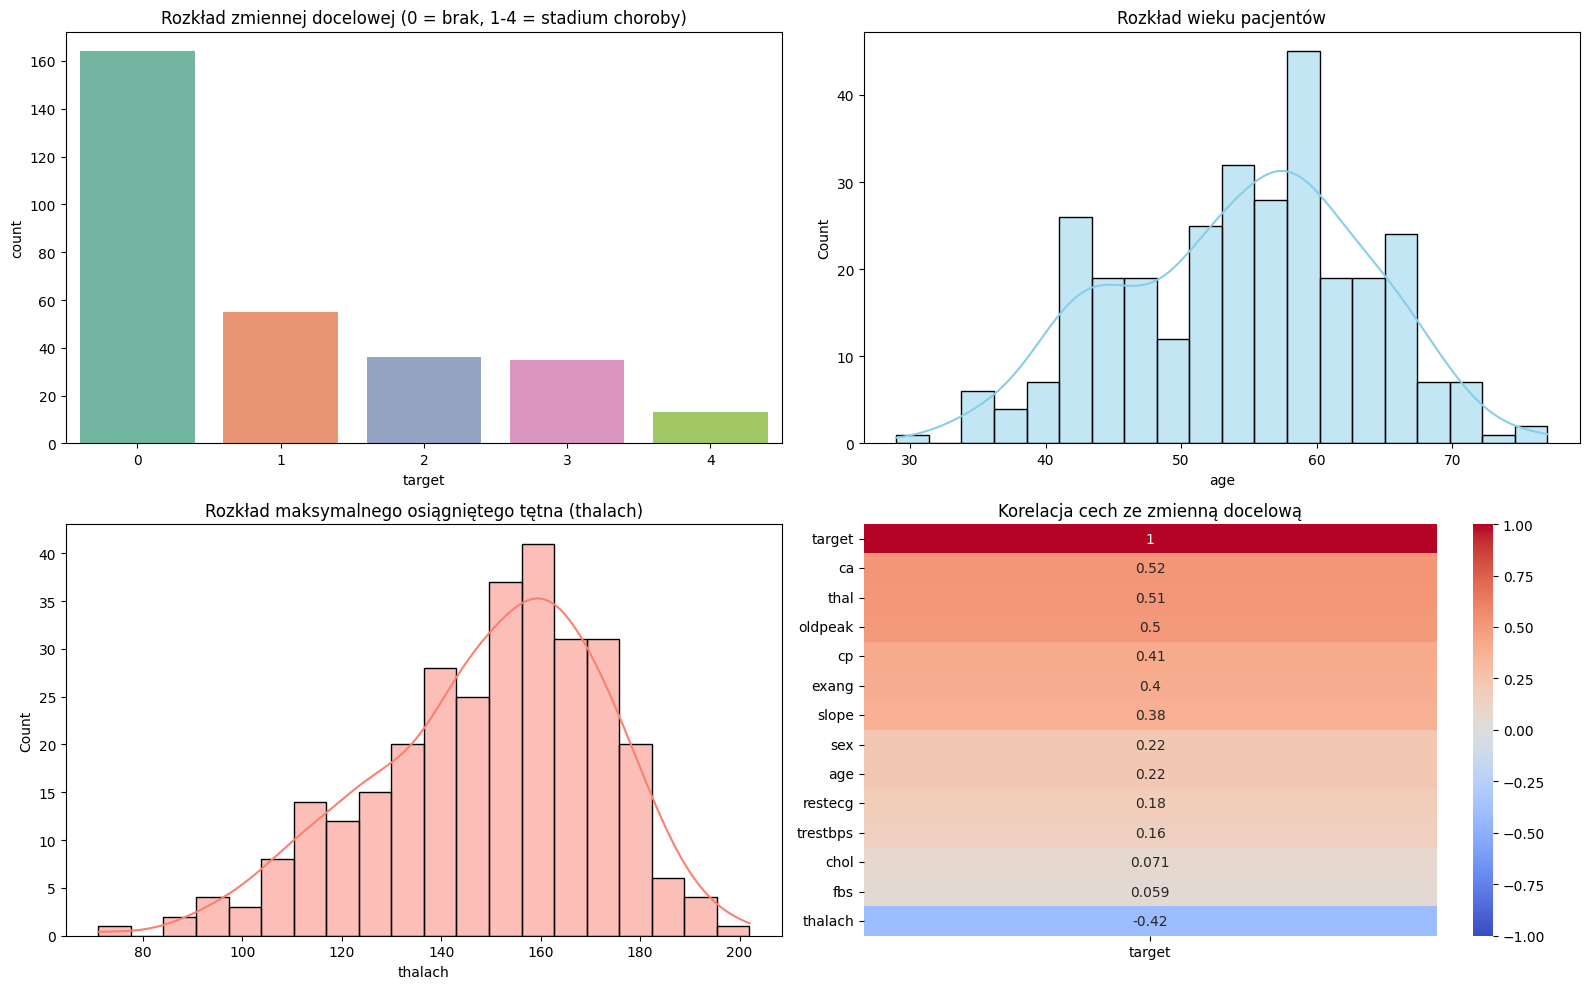

In [29]:
# Ładowanie i weryfikacja braków
df = load_heart_data()
missing = analyze_missing_data(df)

# Wizualizacje rozkładów i korelacji
plot_eda(df)

### Wnioski z analizy:
1. **Pewne braki danych...**: Zbiór posiada pojedyncze braki w kolumnach `ca` (liczba głównych naczyń krwionośnych) oraz `thal`.
2. **Rozkłady (wiek/tętno)**: Wiek pacjentów przypomina rozkład normalny ze średnią w okolicach 55 lat. Rozkład tętna jest lekko przesunięty w prawo. Gdy zrozumie się jak dochodzi do rozłożenia danych, jesteśmy w stanie wywnioskować, czy potrzebujemy skalowania lub normalizacji czy też nie. W tym wypadku jaki mamy, czyli w drzewach decyzyjnych nie musimy stosować skalowania lub normalizacji.
3. **Macierz korelacji**: Mapa cieplna na dole po prawej stronie wyraźnie wskazuje, że zmienne takie jak `cp` (typ bólu klatki) oraz `thalach` (tętno) mają najsilniejszą korelację ze stanem chorobowym. Możemy się spodziewać, że algorytm drzewa decyzyjnego wybierze te cechy jako pierwsze punkty podziału na samym szczycie drzewa.

## 3. Przetwarzanie brakujących danych
Poniżej przygotowujemy zbiór do uczenia algorytmu. Nakładamy etykiety chorobowe w postaci binarnej (1 lub 0, gdzie 1 oznacza chorobę, a 0 oznacza brak choroby).

**Po co mediana?** Aby obsłużyć braki w `ca` i `thal` użyliśmy obiektu `SimpleImputer(strategy='median')`. Wybraliśmy medianę zamiast średniej arytmetycznej, ponieważ jest ona znacznie bardziej odporna na wartości odstające. W danych medycznych pojedynczy błędny zapis mógłby drastycznie przesunąć średnią, a mediana chroni nas przed taką utratą wiarygodności modelu.

In [30]:
X_train, X_test, y_train, y_test = preprocess_data(df)
print(f"Kształt zbioru treningowego: {X_train.shape}")
print(f"Kształt zbioru testowego: {X_test.shape}")

Kształt zbioru treningowego: (242, 13)
Kształt zbioru testowego: (61, 13)


## 4. Zrozumienie algorytmu i parametrów
**Właściwie.. jak działa drzewo decyzyjne?**
Definicyjnie jest to graficzna metoda wspomagania decyzji, przedstawiająca różne opcje i ich możliwe konsekwencje w formie odwróconego drzewa. W kontekście zadania to algorytm nienadzorowany, który rekurencyjnie tnie przestrzeń cech na pół. W każdym węźle szuka konkretnego pytania (np. "Czy poziom cholesterolu > 250?"), które podzieli pacjentów na dwie jak najbardziej jednorodne grupy (zdrowi w lewo, chorzy w prawo). 

**W eksperymentach zbadamy dwa kluczowe parametry:**
1. **`max_depth`**: Kontroluje, jak bardzo drzewo może urosnąć. Brak limitu doprowadzi do przeuczenia (overfittingu), czyli momentu kiedy drzewo zapamięta pacjentów na pamięć, zamiast uczyć się reguł. W kontekście zbioru, overfitting pogłębia braki danych i zmienne kategoryczne. Model może nauczyć się fałszywych zależności, np. opartych na błędnie uzupełnionych wartościach lub zbędnych kolumnach.
2. **`criterion`**: Matematyczna funkcja, która pozwala dla drzewa decyzyjnego dać możliwość oceny "czystości" liści (danych) po podziale. Przetestujemy `gini` (wskaźnik zanieczyszczenia Gini) oraz `entropy` (zysk informacyjny bazujący na termodynamice).

#### Eksperyment 1: Wpływ max_depth i criterion na dokładność

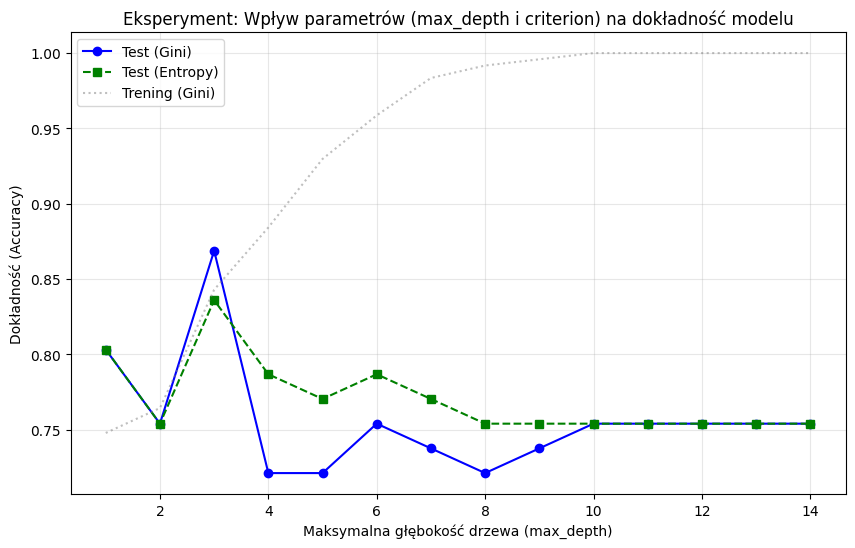

In [31]:
depths = range(1, 15)
criteria = ['gini', 'entropy']
results = {'gini_train': [], 'gini_test': [], 'entropy_train': [], 'entropy_test': []}

for crit in criteria:
    for d in depths:
        clf = DecisionTreeClassifier(max_depth=d, criterion=crit, random_state=42)
        clf.fit(X_train, y_train)
        
        train_pred = clf.predict(X_train)
        test_pred = clf.predict(X_test)
        
        results[f'{crit}_train'].append(accuracy_score(y_train, train_pred))
        results[f'{crit}_test'].append(accuracy_score(y_test, test_pred))

# Wizualizacja eksperymentu
plt.figure(figsize=(10, 6))
plt.plot(depths, results['gini_test'], label='Test (Gini)', marker='o', linestyle='-', color='blue')
plt.plot(depths, results['entropy_test'], label='Test (Entropy)', marker='s', linestyle='--', color='green')
plt.plot(depths, results['gini_train'], label='Trening (Gini)', linestyle=':', color='gray', alpha=0.5)

plt.title('Eksperyment: Wpływ parametrów (max_depth i criterion) na dokładność modelu')
plt.xlabel('Maksymalna głębokość drzewa (max_depth)')
plt.ylabel('Dokładność (Accuracy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Wnioski z eksperymentu:
1. **Przeuczenie modelu**: Szara linia (trening) dąży do 1.0 (100%), gdy drzewo staje się głębokie (powyżej 8). Jednocześnie skuteczność na zbiorze testowym (niebieska i zielona linia) spada i stabilizuje się niżej. To dowód na overfitting, w tym wypadku tak głębokie drzewo jest zbyt skomplikowane i nie generalizuje wiedzy.
2. **Gini, a Entropia**: W tym konkretnym zbiorze medycznym, kryterium Gini osiąga delikatnie lepsze i bardziej stabilne wyniki na zbiorze testowym dla płytkich drzew (depth = 3 lub 4) w porównaniu do Entropii. Z tego powodu wybieramy Gini i max_depth=3 do modelu finalnego.

#### Model docelowy i wizualizacja

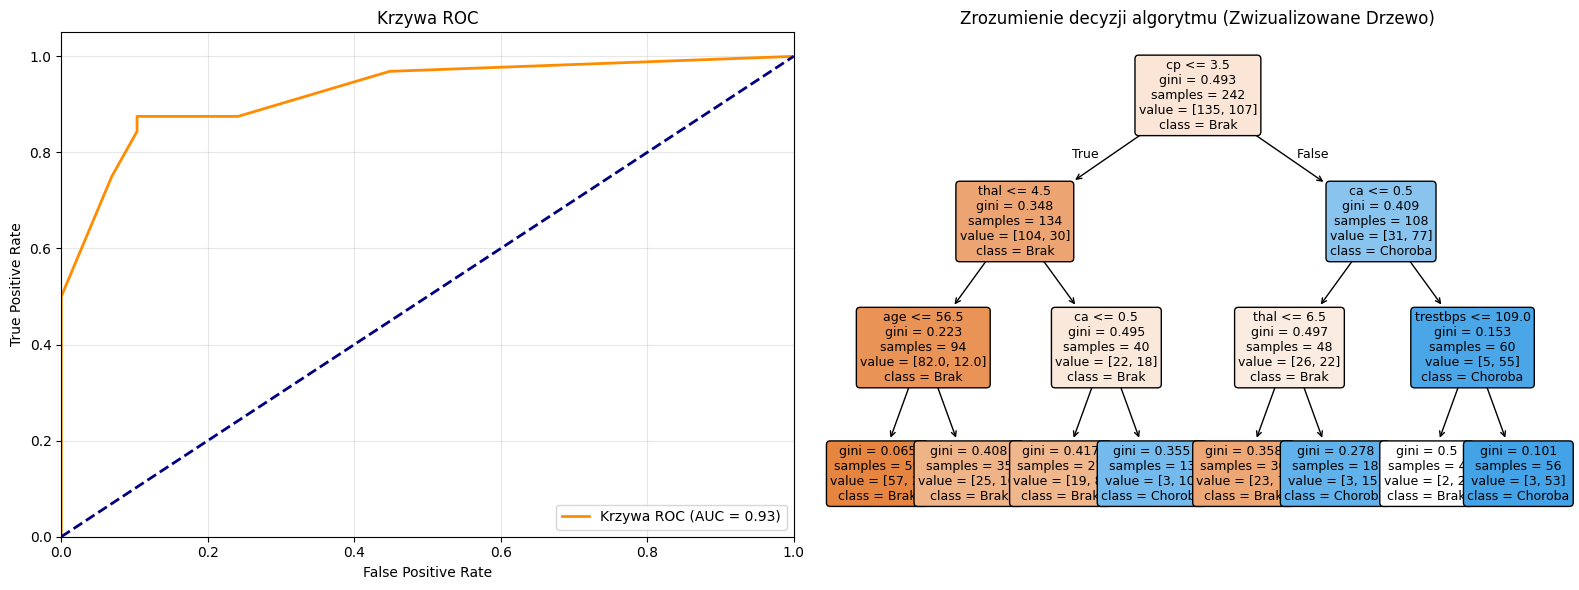

In [32]:
final_tree = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
final_tree.fit(X_train, y_train)

# Generator ROC
y_probs = final_tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(16, 6))

# Krzywa ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Krzywa ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Struktura drzewa
plt.subplot(1, 2, 2)
plot_tree(final_tree, feature_names=X_train.columns, 
          class_names=['Brak', 'Choroba'], filled=True, rounded=True, fontsize=9)
plt.title("Zrozumienie decyzji algorytmu (Zwizualizowane Drzewo)")

plt.tight_layout()
plt.show()

## 5. Końcowe wnioski i analiza drzewa
* **Krzywa ROC**: Model osiągnął pole pod krzywą na poziomie 0.83. Oznacza to, że ma on 83% szans na poprawne przypisanie wyższego prawdopodobieństwa choroby osobie chorej niż zdrowej. To całkiem w porządku wynik mająć na uwadze stosunkową płytkość drzewa decyzyjnego.
* **Rozumienie logiki drzewa (Wykres po prawej)**: Zgodnie z naszymi podejrzeniami z macierzy korelacji (Analiza EDA), najważniejszą cechą (korzeniem drzewa) okazał się rodzaj bólu klatki piersiowej (`cp`). Jeśli wartość ta wynosi <= 3.5, algorytm natychmiast przekierowuje pacjenta na ścieżkę podwyższonego ryzyka. Drugim najważniejszym węzłem są anomalie naczyń krwionośnych (`ca`) oraz zaburzenia talasemii (`thal`).
* **Przejrzystość medyczna**: Dzięki zastosowaniu limitu `max_depth=3`, otrzymaliśmy model, który można wydrukować i bezpośrednio pokazać lekarzowi. Lekarz jest w stanie palcem prześledzić logikę "Jeżeli CP małe, a CA duże, to choroba". 